In [64]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine

In [65]:
df = load_wine()

In [66]:
df

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [67]:
x=df.data
y=df.target

In [68]:
print(df.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [69]:
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([59, 71, 48]))

In [70]:
x.shape

(178, 13)

In [71]:
x[0]

array([1.423e+01, 1.710e+00, 2.430e+00, 1.560e+01, 1.270e+02, 2.800e+00,
       3.060e+00, 2.800e-01, 2.290e+00, 5.640e+00, 1.040e+00, 3.920e+00,
       1.065e+03])

In [72]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=3)

In [73]:
len(x_train)

142

In [74]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [75]:
model = Sequential()

In [76]:
model = Sequential([
    Dense(24,activation='relu',input_shape=(13,)),
    Dense(8,activation ='relu'),
    Dense(3,activation ='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [77]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 24)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 563 (2.20 KB)

 Trainable params: 563 (2.20 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [85]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop= EarlyStopping(patience=10,monitor="val_loss",restore_best_weights=True)
history=model.fit(x_train,y_train,epochs=1000,validation_split=0.2,callbacks=[early_stop])


Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9115 - loss: 0.3031 - val_accuracy: 0.8621 - val_loss: 0.3376
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9027 - loss: 0.3003 - val_accuracy: 0.8621 - val_loss: 0.3534
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8938 - loss: 0.2994 - val_accuracy: 0.8966 - val_loss: 0.3226
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9204 - loss: 0.2958 - val_accuracy: 0.9310 - val_loss: 0.2985
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9027 - loss: 0.3012 - val_accuracy: 0.8966 - val_loss: 0.3114
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9115 - loss: 0.2901 - val_accuracy: 0.8966 - val_loss: 0.3272
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9027 - loss: 0.2882 - val_accuracy: 0.8966 - val_loss: 0.3205
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9204 - loss: 0.2854 - val_accuracy: 0.8621 

In [86]:
y_prob = model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [87]:
y_pred = np.argmax(y_prob, axis=1)

In [88]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.8888888888888888

In [89]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[12  1  0]
 [ 3 13  0]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        13
           1       0.93      0.81      0.87        16
           2       1.00      1.00      1.00         7

    accuracy                           0.89        36
   macro avg       0.91      0.91      0.91        36
weighted avg       0.90      0.89      0.89        36



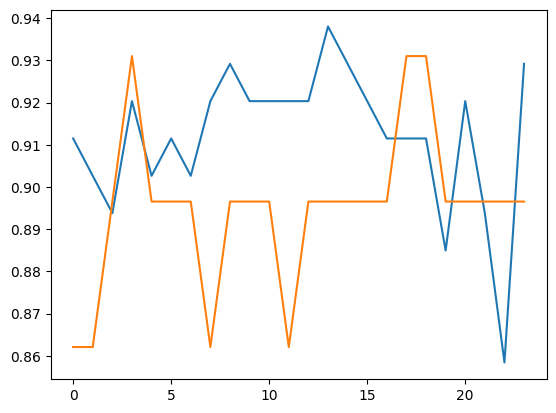

In [90]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

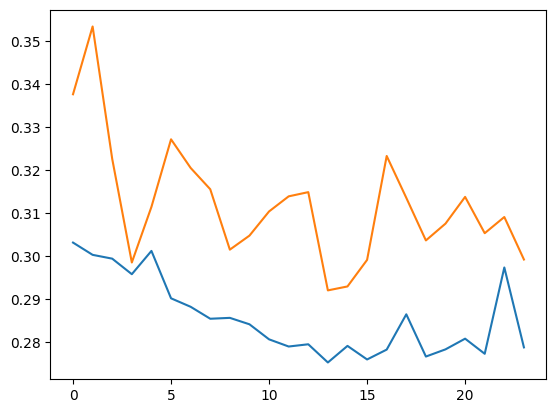

In [91]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])